# **<center style="color: green;">Desafío - Prediciendo los precios de las casas</center>**

#### **Nombre:** Cristian Tobar Morales ###
#### **Curso:** Machine Learning ###

# Descripción
Como Cientista de Datos te han contratado en una importante empresa de propiedades para
analizar las diferentes características de algunas casas que se han vendido en el último
tiempo, y que se encuentran en el dataset house_data.xlsx. Esta base de datos contiene
diversas características de estas propiedades y su precio.

In [1]:
# ==========================================
# 1. Importación de Librerías
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: Preprocesamiento y Selección de Modelos
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Scikit-Learn: Modelos de Regresión
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor

# Scikit-Learn: Métricas de Evaluación de Regresión
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



In [6]:
# ==========================================
# Carga del Dataset y Análisis de Calidad Inicial
# ==========================================
try:
    df = pd.read_excel('/mnt/d/crist/OneDrive/Estudios/Latam_2024/5_Machine Learning/5/house_data.xlsx')
    print("✅ Dataset de propiedades cargado correctamente.\n")
    
    display(df.head())
    
    print("\n--- Información general del dataset ---")
    df.info()
    
    
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo 'house_data.xlsx'.")

✅ Dataset de propiedades cargado correctamente.



,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503



--- Información general del dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  int64  
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613

In [5]:
    # Revisión rápida de valores nulos y duplicados
    print(f"\nTotal de filas duplicadas: {df.duplicated().sum()}")
    print("Total de valores nulos por columna:")
    print(df.isnull().sum())


Total de filas duplicadas: 0
Total de valores nulos por columna:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [8]:
# ==========================================
#  Limpieza de columnas y Análisis Descriptivo
# ==========================================
# Eliminar 'id' y 'date' para evitar ruido en el modelo de regresión
df_clean = df.drop(columns=['id', 'date'])

print("--- Análisis Descriptivo (Estadísticas principales) ---")
# Esto te mostrará la media, desviación estándar, mínimos y máximos de cada variable
display(df_clean.describe())

--- Análisis Descriptivo (Estadísticas principales) ---


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000



--- Correlación de las variables con el Precio ---


price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64

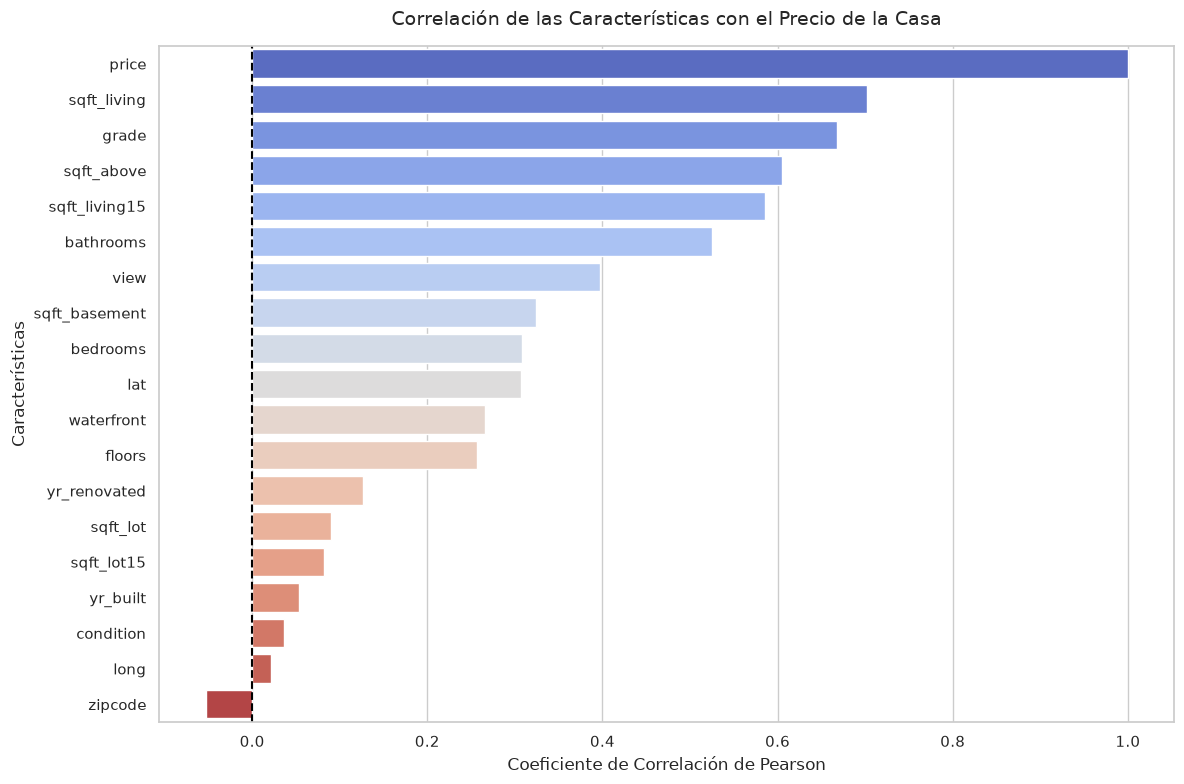

In [9]:
# ==========================================
# Análisis de Correlaciones
# ==========================================
# Calcular la matriz de correlación de Pearson
correlaciones = df_clean.corr()

# Extraer específicamente cómo se correlacionan todas las variables con 'price'
corr_precio = correlaciones['price'].sort_values(ascending=False)

print("\n--- Correlación de las variables con el Precio ---")
display(corr_precio)

# Visualización: Gráfico de barras de las correlaciones
plt.figure(figsize=(12, 8))
# Usamos palette='coolwarm' para distinguir correlaciones positivas (rojo) y negativas (azul)
sns.barplot(x=corr_precio.values, y=corr_precio.index, palette='coolwarm', hue=corr_precio.index, legend=False)
plt.title('Correlación de las Características con el Precio de la Casa', fontsize=14, pad=15)
plt.xlabel('Coeficiente de Correlación de Pearson', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Línea de referencia en el 0
plt.tight_layout()
plt.show()

En el gráfico observamos que la variable objetivo es claramente price (precio). Al responder a la pregunta del desafío "¿Tienen sentido las variables con mayor correlación?", Sí, tienen absoluto sentido.

- Las más altas (`sqft_living`, `grade`, `sqft_above`): El tamaño habitable de la casa (`sqft_living`) y la calidad de la construcción/diseño (`grade`) son, lógicamente, los factores que más encarecen una propiedad en el mundo real.

- Correlaciones moderadas/bajas: Variables como el tamaño del terreno (`sqft_lot`) o el año de construcción (`yr_built`) tienen una correlación positiva mucho más baja, lo cual indica que por sí solas no definen el precio (una casa vieja puede ser cara si está remodelada o tiene buena ubicación).

- Correlaciones negativas: El `zipcode` (código postal) aparece con una ligera correlación negativa, pero esto es un efecto matemático engañoso, ya que el código postal es una variable categórica disfrazada de número.

In [10]:
# ==========================================
# División y Escalado de Datos 
# ==========================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
import time


cols_to_drop = ['price']

X = df_clean.drop(columns=cols_to_drop)
y = df_clean['price']

# División estratificada/aleatoria reservando el 33% para test, como pide el desafío
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Estandarización de las características
# HINT del desafío: fit_transform solo en train, transform en test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Datos divididos y escalados.")
print(f"Set de Entrenamiento: {X_train_scaled.shape[0]} muestras")
print(f"Set de Prueba (Test): {X_test_scaled.shape[0]} muestras\n")


✅ Datos divididos y escalados.
Set de Entrenamiento: 14480 muestras
Set de Prueba (Test): 7133 muestras



In [12]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignorar específicamente las advertencias de convergencia de Scikit-Learn
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==========================================
#  Entrenamiento de Modelos con Regularización 
# ==========================================

# Diccionarios de hiperparámetros proporcionados en el documento
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
elastic_params = {'alpha': [0.001, 0.01, 0.1, 1, 10], 
                  'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
tree_params = {'max_depth': [None, 10, 20, 30], 
               'min_samples_split': [2, 5, 10], 
               'min_samples_leaf': [1, 2, 4]}

# Instanciamos los modelos base
modelos = {
    'Lasso': (Lasso(random_state=42, max_iter=2000), lasso_params),
    'Ridge': (Ridge(random_state=42), ridge_params),
    'Elastic Net': (ElasticNet(random_state=42, max_iter=2000), elastic_params),
    'Decision Tree': (DecisionTreeRegressor(random_state=42), tree_params)
}

# Diccionario para guardar el mejor modelo de cada algoritmo
mejores_modelos = {}
resultados_cv = {}

print("Iniciando optimización de hiperparámetros (GridSearchCV)...")

for nombre, (modelo, parametros) in modelos.items():
    inicio = time.time()
    # Usamos R2 (neg_mean_squared_error también es opción) como métrica de optimización
    grid = GridSearchCV(modelo, parametros, cv=5, scoring='r2', n_jobs=-1)
    
    # Entrenamos con los datos escalados
    grid.fit(X_train_scaled, y_train)
    
    # Guardamos los resultados
    mejores_modelos[nombre] = grid.best_estimator_
    resultados_cv[nombre] = grid.cv_results_
    
    fin = time.time()
    print(f"✅ {nombre} optimizado en {fin - inicio:.1f}s | Mejor R2 CV: {grid.best_score_:.4f}")
    print(f"   Mejores Parámetros: {grid.best_params_}\n")

print("¡Entrenamiento y optimización completados!")

Iniciando optimización de hiperparámetros (GridSearchCV)...
✅ Lasso optimizado en 5.8s | Mejor R2 CV: 0.6988
   Mejores Parámetros: {'alpha': 10}

✅ Ridge optimizado en 0.3s | Mejor R2 CV: 0.6988
   Mejores Parámetros: {'alpha': 10}

✅ Elastic Net optimizado en 8.5s | Mejor R2 CV: 0.6988
   Mejores Parámetros: {'alpha': 0.01, 'l1_ratio': 0.3}

✅ Decision Tree optimizado en 12.5s | Mejor R2 CV: 0.7966
   Mejores Parámetros: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

¡Entrenamiento y optimización completados!


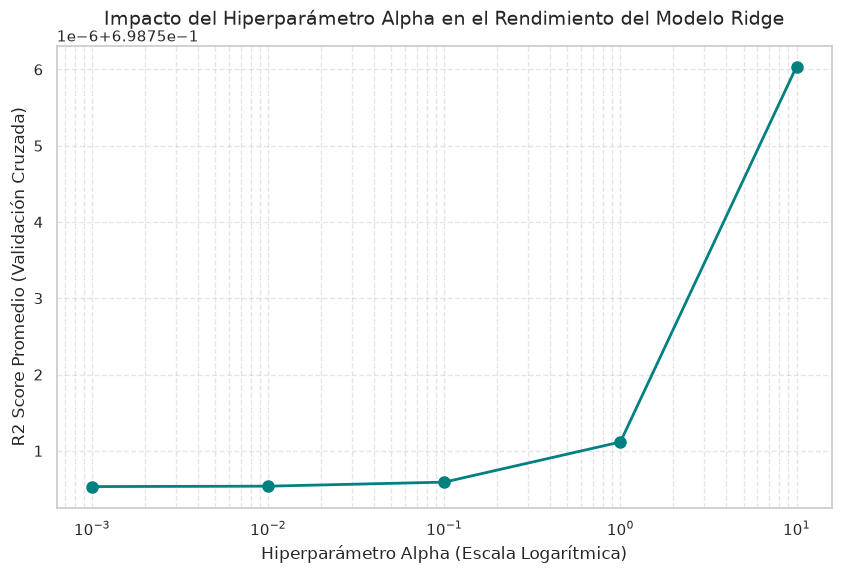


Iniciando evaluación final con el conjunto de Prueba (Test)...

=== Cuadro Comparativo de Rendimiento (Test Set) ===


,MSE,MAE,R2
Decision Tree,3.007394e+10,91918.902987,0.799147
Lasso,4.542669e+10,126908.865892,0.696612
Ridge,4.543058e+10,126887.915239,0.696586
Elastic Net,4.547369e+10,126707.248248,0.696298


In [13]:
# ==========================================
# Análisis de Hiperparámetros 
# ==========================================
import matplotlib.pyplot as plt

# Extraemos los valores de alpha y los resultados de R2 para Ridge
alphas_ridge = ridge_params['alpha']
# 'mean_test_score' guarda el R2 promedio de los 5 pliegues de validación cruzada para cada alpha
r2_scores_ridge = resultados_cv['Ridge']['mean_test_score']

# Generamos el gráfico
plt.figure(figsize=(10, 6))
plt.plot(alphas_ridge, r2_scores_ridge, marker='o', linestyle='-', color='teal', linewidth=2, markersize=8)

# Usamos escala logarítmica en el eje X porque los alphas van de 0.001 a 10 (saltos exponenciales)
plt.xscale('log')
plt.xlabel('Hiperparámetro Alpha (Escala Logarítmica)', fontsize=12)
plt.ylabel('R2 Score Promedio (Validación Cruzada)', fontsize=12)
plt.title('Impacto del Hiperparámetro Alpha en el Rendimiento del Modelo Ridge', fontsize=14, pad=15)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ==========================================
# 6. Evaluación Final y Cuadro Comparativo (Req. 6)
# ==========================================
print("\nIniciando evaluación final con el conjunto de Prueba (Test)...\n")

resultados_test = {}

# Evaluamos cada uno de los modelos ganadores con los datos que nunca han visto (X_test_scaled)
for nombre, modelo in mejores_modelos.items():
    # 1. Predecir
    y_pred = modelo.predict(X_test_scaled)
    
    # 2. Calcular Métricas
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # 3. Guardar en el diccionario
    resultados_test[nombre] = {
        'MSE': mse,
        'MAE': mae,
        'R2': r2
    }

# Convertimos el diccionario a un DataFrame para crear el cuadro comparativo
df_comparativo = pd.DataFrame(resultados_test).T

# Mostramos el cuadro ordenado desde el mejor R2 al peor
print("=== Cuadro Comparativo de Rendimiento (Test Set) ===")
display(df_comparativo.sort_values(by='R2', ascending=False))

# Conclusiones
1. Análisis de la Regularización (Modelo Ridge)
Al observar el gráfico de la variación del hiperparámetro alpha en el modelo Ridge, notamos un comportamiento interesante. Aunque la línea visualmente muestra una pendiente ascendente hacia el final, si observamos la escala del eje Y (con variaciones en el orden de 1e-6), el puntaje R2 de validación cruzada se mantuvo prácticamente estático alrededor de 0.698. Esto nos indica que, para este conjunto de datos específico, aplicar penalizaciones más fuertes a los coeficientes lineales no generó un cambio drástico en la capacidad predictiva del modelo.

2. El Modelo Ganador: Árbol de Decisión (Decision Tree)
Al revisar el cuadro comparativo de rendimiento sobre los datos de prueba (datos no vistos previamente por los algoritmos), el claro ganador indiscutible es el Árbol de Decisión.

    - Capacidad Explicativa (R2): Logró un R2 de 0.799, lo que significa que el modelo es capaz de explicar prácticamente el 80% de la variabilidad en los precios de las casas.

    - Margen de Error (MAE): Presentó el Error Absoluto Medio más bajo, rondando los $91,918. Aunque parece un número alto, en el contexto de bienes raíces es significativamente mejor que el error de sus competidores.

3. Relaciones Lineales vs. No Lineales
Los tres modelos lineales (Lasso, Ridge y Elastic Net) tuvieron un rendimiento estancado y casi idéntico, logrando un R2 de 0.696 y equivocándose por un promedio de ~$126,000 (MAE).

El hecho de que el Árbol de Decisión los haya superado por un margen tan amplio (una diferencia de 10 puntos porcentuales en el R2 y más de $34,000 menos en el margen de error) demuestra de manera contundente que la naturaleza de los precios inmobiliarios en este dataset no es puramente lineal. Existen interacciones complejas e inflexiones entre las variables (por ejemplo, el impacto del tamaño del terreno frente a la calidad de la construcción en distintos códigos postales) que los modelos lineales no pueden capturar, pero que un algoritmo basado en particiones sí logra descifrar con éxito.